# Tip 2 — Reversal vs. Momentum, Separated by Horizon

Key insight: short-term reversal and longer-term momentum are distinct signals — blending them into one number destroys information. Give the model both explicitly.

**Features added:**
1. Directional momentum sums at short (1–3), medium (1–5, 1–10), and long (1–20) horizons
2. Momentum acceleration (short − medium, medium − long, short − long differences)
3. EWMA of returns at two decay rates (half-life 2 and half-life 5 days)
4. Standardized reversal: `RET_1 / std(RET_1..20)` — how extreme the last move was vs. the strategy's own 20-day vol

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import lightgbm as lgbm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

### Load data

In [15]:
X_train = pd.read_csv('../../data/X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('../../data/X_test.csv', index_col='ROW_ID')
y_train = pd.read_csv('../../data/y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('../../submission/sample_submission.csv', index_col='ROW_ID')

RET_cols = [f'RET_{i}'           for i in range(1, 21)]
VOL_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

### Feature engineering

#### A. Benchmark features (rolling means, cross-alloc means, vol)

In [16]:
def add_benchmark_features(df):
    for i in [3, 5, 10, 15, 20]:
        df[f'AVERAGE_PERF_{i}'] = df[RET_cols[:i]].mean(axis=1)
        df[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')
    df['STD_PERF_20'] = df[RET_cols].std(axis=1)
    df['ALLOCATIONS_STD_PERF_20'] = df.groupby('TS')['STD_PERF_20'].transform('mean')
    return df

X_train = add_benchmark_features(X_train)
X_test  = add_benchmark_features(X_test)

#### B. Tip 2a — Momentum sums at distinct horizons

Sum (not mean) of returns over short (1–3), medium (1–5, 1–10), and long (1–20) windows keeps the scale signal that a mean would wash out. The model sees each horizon as a separate feature rather than one blended number.

In [17]:
def add_momentum_features(df):
    mom_features = []
    for horizon, name in [(3, 'SHORT'), (5, 'MED5'), (10, 'MED10'), (20, 'LONG')]:
        col = f'MOM_SUM_{name}'
        df[col] = df[RET_cols[:horizon]].sum(axis=1)
        mom_features.append(col)
    return df, mom_features

X_train, mom_features = add_momentum_features(X_train)
X_test,  _            = add_momentum_features(X_test)
print("Momentum features:", mom_features)

Momentum features: ['MOM_SUM_SHORT', 'MOM_SUM_MED5', 'MOM_SUM_MED10', 'MOM_SUM_LONG']


#### C. Tip 2b — Momentum acceleration (differences between horizons)

`short − medium` captures whether recent returns are accelerating or fading relative to the longer trend. Positive = recent surge; negative = recent fade/reversal.

In [18]:
def add_acceleration_features(df):
    accel_features = []
    pairs = [
        ('MOM_SUM_SHORT', 'MOM_SUM_MED5',  'ACCEL_S_M5'),
        ('MOM_SUM_MED5',  'MOM_SUM_MED10', 'ACCEL_M5_M10'),
        ('MOM_SUM_MED10', 'MOM_SUM_LONG',  'ACCEL_M10_L'),
        ('MOM_SUM_SHORT', 'MOM_SUM_LONG',  'ACCEL_S_L'),
    ]
    for col_a, col_b, name in pairs:
        df[name] = df[col_a] - df[col_b]
        accel_features.append(name)
    return df, accel_features

X_train, accel_features = add_acceleration_features(X_train)
X_test,  _              = add_acceleration_features(X_test)
print("Acceleration features:", accel_features)

Acceleration features: ['ACCEL_S_M5', 'ACCEL_M5_M10', 'ACCEL_M10_L', 'ACCEL_S_L']


#### D. Tip 2c — EWMA at two decay rates

An exponentially-weighted mean gives more weight to recent days than a simple sum. Using two half-lives (2 and 5 days) lets the model compare how fast returns are decaying.

In [19]:
def ewma_weights(half_life, n=20):
    """Weights for lags 1..n, most recent = lag 1 (highest weight)."""
    alpha = 1 - np.exp(-np.log(2) / half_life)
    w = np.array([(1 - alpha) ** (k - 1) for k in range(1, n + 1)])
    return w / w.sum()

def add_ewma_features(df):
    ewma_features = []
    for hl in [1, 2, 3, 5, 7, 10, 15]:
        w   = ewma_weights(hl, n=20)
        col = f'EWMA_HL{hl}'
        df[col] = df[RET_cols].values @ w
        ewma_features.append(col)
    return df, ewma_features

X_train, ewma_features = add_ewma_features(X_train)
X_test,  _             = add_ewma_features(X_test)
print("EWMA features:", ewma_features)

EWMA features: ['EWMA_HL1', 'EWMA_HL2', 'EWMA_HL3', 'EWMA_HL5', 'EWMA_HL7', 'EWMA_HL10', 'EWMA_HL15']


#### E. Tip 2d — Standardized reversal (`RET_1 / 20-day vol`)

How extreme was the most recent move relative to this strategy's own historical volatility? A large magnitude here signals an unusual event likely to mean-revert.

In [20]:
def add_reversal_features(df):
    vol20 = df[RET_cols].std(axis=1).replace(0, np.nan)
    df['STD_REVERSAL'] = df['RET_1'] / vol20          # standardized surprise
    df['ABS_STD_REVERSAL'] = df['STD_REVERSAL'].abs()  # magnitude of the surprise
    return df, ['STD_REVERSAL', 'ABS_STD_REVERSAL']

X_train, reversal_features = add_reversal_features(X_train)
X_test,  _                 = add_reversal_features(X_test)
print("Reversal features:", reversal_features)

Reversal features: ['STD_REVERSAL', 'ABS_STD_REVERSAL']


### Build final feature list

In [21]:
benchmark_features = (
    RET_cols + VOL_cols + ['MEDIAN_DAILY_TURNOVER']
    + [f'AVERAGE_PERF_{i}'             for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
    + ['STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']
)

tip2_features = mom_features + accel_features + ewma_features + reversal_features

features = benchmark_features + tip2_features
print(f"Total features: {len(features)}  "
      f"(benchmark={len(benchmark_features)}, tip2={len(tip2_features)})")
print("Tip2 features:", tip2_features)

Total features: 70  (benchmark=53, tip2=17)
Tip2 features: ['MOM_SUM_SHORT', 'MOM_SUM_MED5', 'MOM_SUM_MED10', 'MOM_SUM_LONG', 'ACCEL_S_M5', 'ACCEL_M5_M10', 'ACCEL_M10_L', 'ACCEL_S_L', 'EWMA_HL1', 'EWMA_HL2', 'EWMA_HL3', 'EWMA_HL5', 'EWMA_HL7', 'EWMA_HL10', 'EWMA_HL15', 'STD_REVERSAL', 'ABS_STD_REVERSAL']


### LightGBM — 8-fold cross-validation on dates

In [22]:
lgbm_params = {
    "objective":     "mse",
    "metric":        "mse",
    "num_threads":   50,
    "seed":          42,
    "verbosity":     -1,
    "learning_rate": 1e-2,
    "max_depth":     3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
n_splits    = 8
scores      = []
models      = []

splits = KFold(n_splits=n_splits, shuffle=True, random_state=0).split(train_dates)

for fold, (tr_idx, val_idx) in enumerate(splits):
    tr_dates  = train_dates[tr_idx]
    val_dates = train_dates[val_idx]

    tr_mask  = X_train['TS'].isin(tr_dates)
    val_mask = X_train['TS'].isin(val_dates)

    X_tr  = X_train.loc[tr_mask,  features].fillna(0)
    y_tr  = y_train.loc[tr_mask,  'target']
    X_val = X_train.loc[val_mask, features].fillna(0)
    y_val = y_train.loc[val_mask, 'target']

    train_data = lgbm.Dataset(X_tr, label=y_tr.values)
    model      = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)

    preds = model.predict(X_val.values, num_threads=lgbm_params['num_threads'])
    acc   = accuracy_score((y_val > 0).astype(int), (preds > 0).astype(int))

    models.append(model)
    scores.append(acc)
    print(f"Fold {fold+1} — Accuracy: {acc*100:.2f}%")

mean = np.mean(scores) * 100
std  = np.std(scores)  * 100
print(f"\nAccuracy: {mean:.2f}% ± {std:.2f}%  [{mean-std:.2f} ; {mean+std:.2f}]")

Fold 1 — Accuracy: 52.19%
Fold 2 — Accuracy: 52.25%
Fold 3 — Accuracy: 51.93%
Fold 4 — Accuracy: 52.00%
Fold 5 — Accuracy: 51.79%
Fold 6 — Accuracy: 52.31%
Fold 7 — Accuracy: 52.45%
Fold 8 — Accuracy: 52.14%

Accuracy: 52.13% ± 0.20%  [51.93 ; 52.33]


### Feature importance (top 30 by gain)

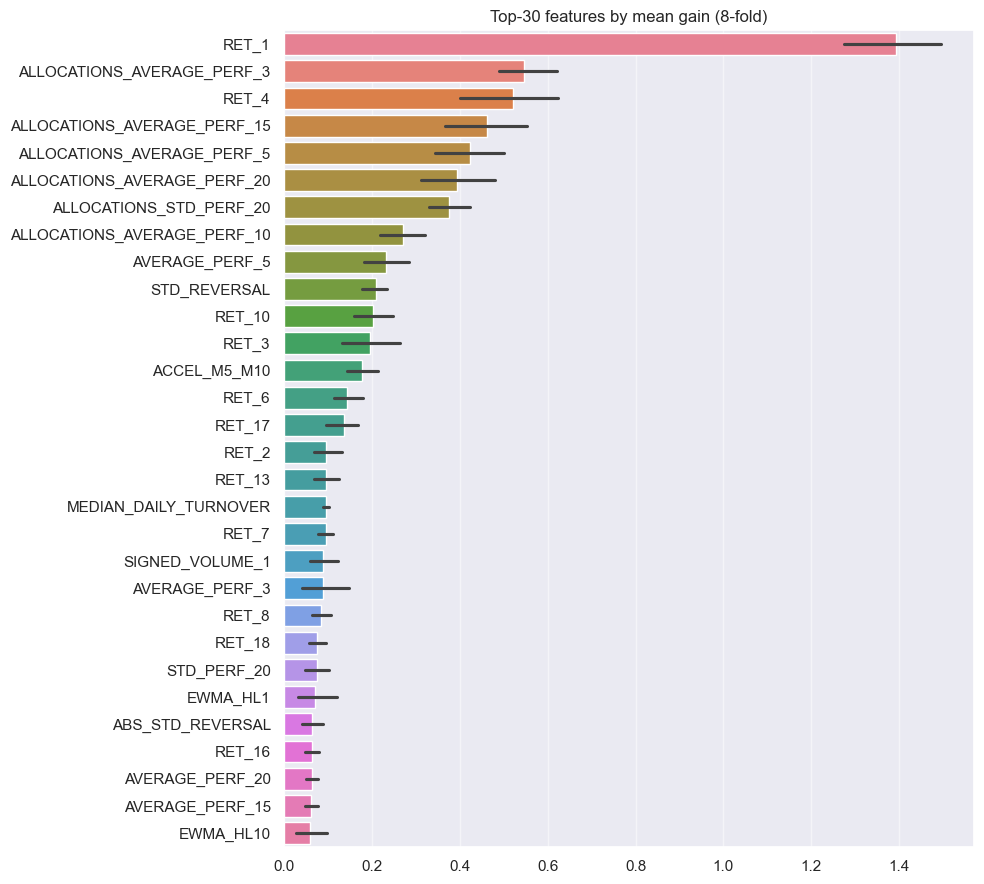

In [23]:
importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models],
    columns=features
)
top30 = importances.mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(10, 9))
sns.barplot(
    data=importances[top30],
    orient='h',
    order=importances[top30].mean().sort_values(ascending=False).index
)
plt.title("Top-30 features by mean gain (8-fold)")
plt.tight_layout()
plt.show()

### Final model — train on all data and write submission

In [24]:
full_train_data = lgbm.Dataset(X_train[features].fillna(0), label=y_train['target'].values)
final_model     = lgbm.train(lgbm_params, full_train_data, num_boost_round=NUM_BOOST_ROUND)

test_preds = final_model.predict(X_test[features].fillna(0).values)
submission = pd.DataFrame(
    (test_preds > 0).astype(int),
    index=sample_submission.index,
    columns=['TARGET']
)
submission.to_csv('preds_tip2_reversal_momentum.csv')
print("Saved preds_tip2_reversal_momentum.csv")
submission['TARGET'].value_counts()

Saved preds_tip2_reversal_momentum.csv


TARGET
1    18954
0    12916
Name: count, dtype: int64